# Phi Projection Scaling

In [13]:
sizes = [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000]
nnz_per_row = 4
proj_dim = 16
seed = 0

In [14]:
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch

In [15]:
def build_sparse_phi(num_nodes, nnz_per_row, seed):
    gen = torch.Generator().manual_seed(seed)
    row_idx = torch.arange(num_nodes).repeat_interleave(nnz_per_row)
    col_idx = torch.randint(num_nodes, (num_nodes * nnz_per_row,), generator=gen)
    values = torch.randn(num_nodes * nnz_per_row, generator=gen)
    phi = torch.sparse_coo_tensor(
        torch.stack([row_idx, col_idx]),
        values,
        size=(num_nodes, num_nodes),
    ).coalesce()
    return phi


def sparse_memory_bytes(phi):
    return phi.indices().element_size() * phi.indices().numel() + phi.values().element_size() * phi.values().numel()


def dense_memory_bytes(tensor):
    return tensor.element_size() * tensor.numel()

In [16]:
rows = []

for num_nodes in sizes:
    phi = build_sparse_phi(num_nodes, nnz_per_row, seed)
    gaussian = torch.randn(num_nodes, proj_dim)

    start = time.perf_counter()
    projected = torch.sparse.mm(phi, gaussian)
    elapsed = time.perf_counter() - start

    rows.append(
        {
            "N": num_nodes,
            "nnz": phi._nnz(),
            "nnz_per_row_actual": phi._nnz() / num_nodes,
            "proj_dim": proj_dim,
            "time_seconds": elapsed,
            "phi_memory_mb": sparse_memory_bytes(phi) / 1024**2,
            "gaussian_memory_mb": dense_memory_bytes(gaussian) / 1024**2,
            "projected_memory_mb": dense_memory_bytes(projected) / 1024**2,
        }
    )

results = pd.DataFrame(rows)
results

,N,nnz,nnz_per_row_actual,proj_dim,time_seconds,phi_memory_mb,gaussian_memory_mb,projected_memory_mb
0,500,1994,3.988000,16,0.000601,0.038033,0.030518,0.030518
1,1000,3991,3.991000,16,0.000078,0.076122,0.061035,0.061035
2,2000,7994,3.997000,16,0.000103,0.152473,0.122070,0.122070
3,4000,15996,3.999000,16,0.000375,0.305099,0.244141,0.244141
4,8000,31997,3.999625,16,0.000704,0.610294,0.488281,0.488281
5,16000,63995,3.999687,16,0.001895,1.220608,0.976562,0.976562
6,32000,127995,3.999844,16,0.002457,2.441311,1.953125,1.953125
7,64000,255995,3.999922,16,0.008557,4.882717,3.906250,3.906250
8,128000,511994,3.999953,16,0.013180,9.765511,7.812500,7.812500
9,256000,1023997,3.999988,16,0.031046,19.531193,15.625000,15.625000


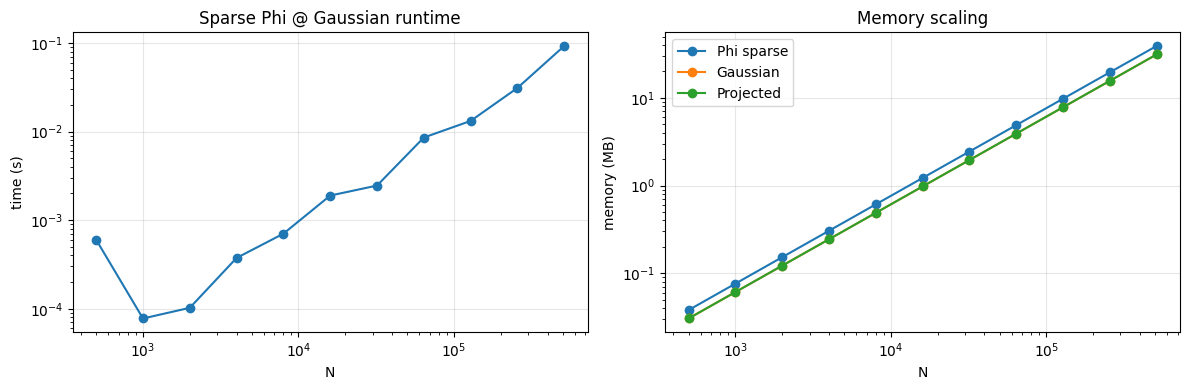

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results["N"], results["time_seconds"], marker="o")
axes[0].set_xlabel("N")
axes[0].set_ylabel("time (s)")
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title("Sparse Phi @ Gaussian runtime")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results["N"], results["phi_memory_mb"], marker="o", label="Phi sparse")
axes[1].plot(results["N"], results["gaussian_memory_mb"], marker="o", label="Gaussian")
axes[1].plot(results["N"], results["projected_memory_mb"], marker="o", label="Projected")
axes[1].set_xlabel("N")
axes[1].set_ylabel("memory (MB)")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title("Memory scaling")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()